# Plotting from `n.statistics`

A guided ~40-min follow-up to the statistics session. Every `n.statistics.<method>`
exposes two plotting accessors:

- `.plot`  — matplotlib/seaborn, static
- `.iplot` — plotly, interactive

All the familiar statistics filters (`carrier`, `bus_carrier`, `nice_names`) pass
straight through. Layout (`x`, `y`, `color`, `facet_col`, `facet_row`) replaces the
`groupby*` knobs from the raw API.

We reuse `pypsa.examples.carbon_management()` from the previous session.

In [1]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
import plotly.graph_objects as go
pio.renderers.default = "notebook_connected"

n = pypsa.examples.carbon_management()
n.carriers["nice_name"] = n.carriers["nice_name"].str.replace(r"\$_2\$", "₂", regex=True) # monkey patch another rendering issue with latex exprs
s = n.statistics

INFO:pypsa.network.io:Imported network 'Hybrid Scenario from https://www.nature.com/articles/s41560-025-01752-6' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [2]:
# monkey patch a bug in pypsa 1.2.1 (to be fixed soon)
import plotly.graph_objects as go

_orig_show = go.Figure._ipython_display_

def _is_categorical(yaxis_name, fig):
    ax = fig.layout[yaxis_name]
    if ax.type in ("category", "multicategory"):
        return True
    if ax.type in ("linear", "log", "date"):
        return False
    suffix = yaxis_name.removeprefix("yaxis")
    target = "y" + suffix
    for tr in fig.data:
        if (tr.yaxis or "y") == target and tr.y is not None and len(tr.y):
            return isinstance(tr.y[0], str)
    return False

def _show(self):
    for name in self.layout:
        if name.startswith("yaxis") and _is_categorical(name, self):
            self.layout[name].update(tickmode="linear", dtick=1)
    return _orig_show(self)

go.Figure._ipython_display_ = _show

:::{tip}
Same `s = n.statistics` shorthand from last session — now `s.capex.plot.bar(...)` is the pattern.
:::

# Why use the accessors?

Last session ended with `eb.xs(...).droplevel(0).sort_values().plot.barh(...)`. That works,
but you carry reshape logic yourself. The accessors handle filtering, layout, units, nice
names, and pick carrier colors from `n.carriers.color` automatically.

<Axes: xlabel='MWh', ylabel='carrier'>

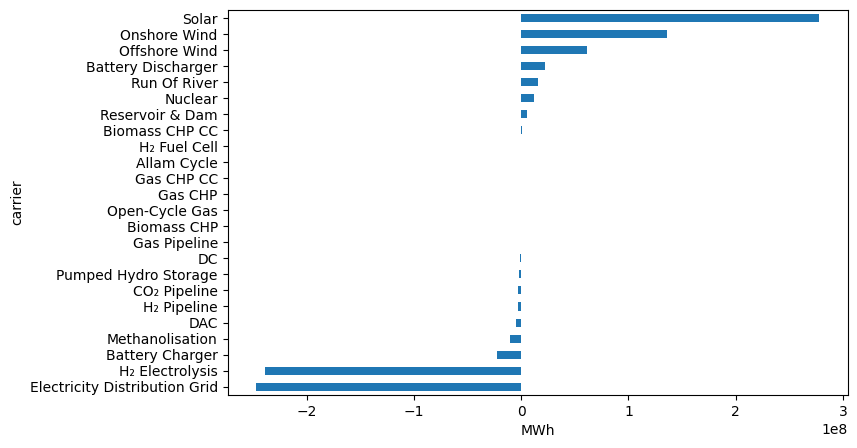

In [3]:
# manual way (recap from last session)
eb = s.energy_balance()
eb.xs("AC", level="bus_carrier").droplevel(0).sort_values().plot.barh(figsize=(8, 5), xlabel="MWh")

(<Figure size 811.111x400 with 1 Axes>,
 <Axes: xlabel='Energy Balance [MWh_el]', ylabel='carrier'>,
 <seaborn.axisgrid.FacetGrid at 0x740006cbefc0>)

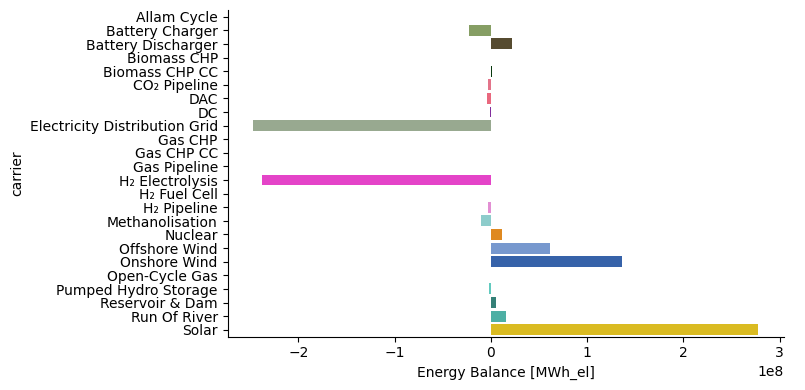

In [4]:
# accessor way — same result, one line, carrier colors applied
s.energy_balance.plot.bar(bus_carrier="AC", aspect=2)

:::{note}
The accessor is called on the **method itself**, not on its return value:
`s.capex.plot.bar()` ✅ — `s.capex().plot.bar()` is plain pandas and loses the schema/colors.
:::

:::{important}
- `.plot.*` returns `(fig, ax, FacetGrid)`
- `.iplot.*` returns a `plotly.graph_objects.Figure`

Unpack as `fig, ax, g = s.capex.plot.bar()` if you want to keep editing the axes.
:::

# `.plot` vs `.iplot`

| Accessor | Backend | Use for | Plot types |
|---|---|---|---|
| `.plot` | matplotlib/seaborn | reports, papers, slides, PNG/PDF | `bar`, `line`, `area`, `scatter`, `box`, `violin`, `histogram`, `map` |
| `.iplot` | plotly | exploration, hover, zoom, HTML export | `bar`, `line`, `area` only |

:::{warning}
`.iplot.scatter`, `.iplot.box`, `.iplot.violin`, `.iplot.histogram`, `.iplot.map`
all raise. Plotly coverage in the accessor is limited to `bar`/`line`/`area`. For
distributions and maps, use `.plot.*`.
:::

(<Figure size 811.111x400 with 1 Axes>,
 <Axes: xlabel='Capital Expenditure [currency]', ylabel='carrier'>,
 <seaborn.axisgrid.FacetGrid at 0x740006d7deb0>)

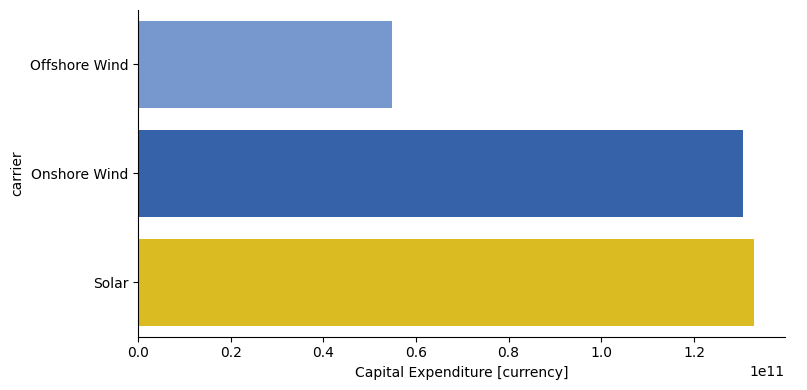

In [5]:
s.capex.plot.bar(carrier=["solar", "onwind", "offwind"], aspect=2)

In [6]:
s.capex.iplot.bar(carrier=["solar", "onwind", "offwind"])

# Plot types

One representative carbon_management example per plot type. Each call pulls a
different statistics method and exercises a different filter / layout kwarg.

## `bar` — categorical totals

The workhorse. Default is horizontal bars (`x="value"`, `y="carrier"`), stacked
by carrier color.

In [8]:
s.capex.iplot.bar()
# s.capex.plot.bar(aspect=2, height=7)

In [10]:
# bus_carrier filter; grouped bars instead of stacked
s.capex.iplot.bar(bus_carrier="AC")
# s.capex.plot.bar(bus_carrier="AC", stacked=False, aspect=2, height=6)

In [12]:
fig = s.optimal_capacity.iplot.bar(bus_carrier=["AC", "low voltage"], facet_col="bus_carrier")
fig.update_layout(showlegend=False)

# s.optimal_capacity.plot.bar(bus_carrier=["AC", "low voltage"], facet_col="bus_carrier", height=6)

In [14]:
countries = ["DE", "FR", "IT"]
query = f"country in {countries}"

s.supply.iplot.bar(x="bus_carrier", y="value", color="carrier", facet_row="country", sharey=False, query=query)

# s.supply.plot.bar(x="bus_carrier", y="value", color="carrier", facet_row="country", sharey=False, query=query, aspect=2)

/home/fabian/vres/py/oet/pypsa-training-sessions/.venv/lib/python3.12/site-packages/pypsa/plot/statistics/charts.py:644: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



:::{tip}
`query="value > 0"` is a handy pandas-style filter on the long-format frame —
useful for dropping zeros from a busy bar chart.
:::

## `line` — time series

For time-resolved statistics (`energy_balance`, `supply`, `withdrawal`, `opex`, …)
the schema already defaults `x="snapshot"`, so a plain call returns a snapshot-wise line.

In [16]:
s.energy_balance.iplot.line(bus_carrier="AC", carrier=["solar", "onwind", "nuclear"], color="carrier")
# s.energy_balance.plot.line(bus_carrier="AC", carrier=["solar", "onwind", "nuclear"], color="carrier")

In [23]:
# explicit x="snapshot" + color by carrier
s.supply.iplot.line(bus_carrier=["AC", "low voltage"], x="snapshot", color="carrier", facet_col="bus_carrier", facet_row="country", query=query)

:::{note}
To go back to a non-time-series view, override `x` to a categorical column (e.g. `x="carrier"`).
:::

## `area` — stacked dispatch

The classic stacked dispatch plot in one call. `energy_balance` defaults to
`kind="area"`, so `.plot()` alone works.

In [14]:
s.energy_balance.iplot.area(bus_carrier="AC")

In [26]:
# H2 sector balance, static
s.energy_balance.iplot.area(bus_carrier=["H2", "AC"], facet_row="bus_carrier")

:::{tip}
Mixed-sign areas (positive supply / negative withdrawal) are split by sign and
stacked separately — no extra config needed.
:::

## Parameter pass-through recap

Every plot type accepts the statistics filter kwargs:

In [54]:
s.supply.iplot.bar(
    bus_carrier="AC",
    carrier=["solar", "onwind", "offwind-ac", "OCGT"],
    nice_names=True,
)

:::{warning}
Three statistics kwargs are **reserved** — passing them raises `ValueError`:

- `groupby` — derived from `x` / `y` / `color` / `facet_*`
- `groupby_time` — set to `"sum"` unless `snapshot` appears in a layout kwarg
- `aggregate_across_components` — set to `True` unless `component` appears in a layout kwarg

For a time series, set `x="snapshot"` (or pick a stat where it's already the
default). To split by component, set `color="component"`.
:::

# Spatial view — `.plot.map`

The headline of the session. `.plot.map` draws bus-level statistics as scaled
circles on the network and branch-level statistics (or transmission flows) as
line widths / arrows. Built from any statistics method except `prices`.

:::{warning}
There is **no `.iplot.map`** in PyPSA 1.2.1 — `StatisticInteractivePlotter` doesn't
expose it. For interactive geographic plots, fall back to `n.iplot()` directly.
:::

:::{important}
`prices.plot.map` raises `NotImplementedError`. Every other statistic supports the map.
:::

/home/fabian/vres/py/oet/pypsa-training-sessions/.venv/lib/python3.12/site-packages/pypsa/plot/statistics/maps.py:253: UserWarning:

When combining n.plot() with other plots on a geographical axis, ensure n.plot() is called first or the final axis extent is set initially (ax.set_extent(boundaries, crs=crs)) for consistent legend circle sizes.



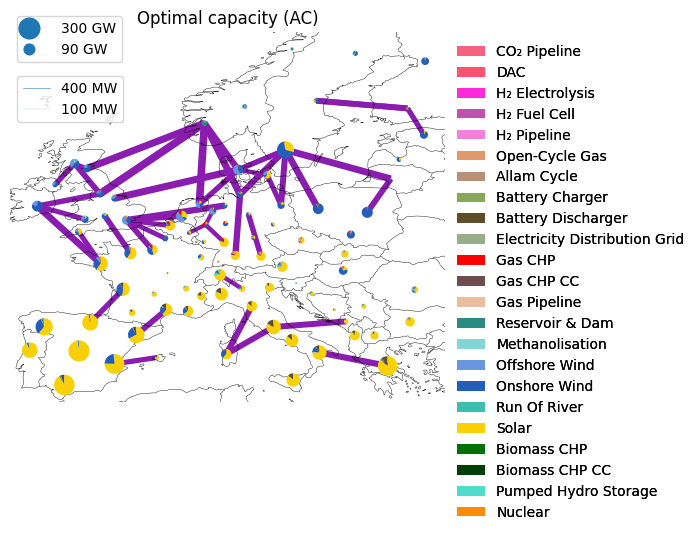

In [56]:
# optimal capacity on the AC layer
fig, ax = s.optimal_capacity.plot.map(bus_carrier="AC", title="Optimal capacity (AC)")

/home/fabian/vres/py/oet/pypsa-training-sessions/.venv/lib/python3.12/site-packages/pypsa/plot/statistics/maps.py:253: UserWarning:

When combining n.plot() with other plots on a geographical axis, ensure n.plot() is called first or the final axis extent is set initially (ax.set_extent(boundaries, crs=crs)) for consistent legend circle sizes.



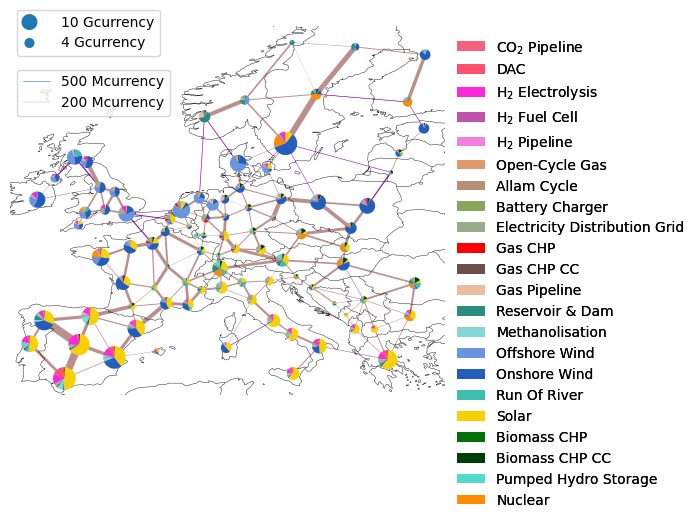

In [20]:
# capex on the map
fig, ax = s.capex.plot.map(bus_carrier="AC")

/home/fabian/vres/py/oet/pypsa-training-sessions/.venv/lib/python3.12/site-packages/pypsa/plot/statistics/maps.py:238: UserWarning:

When combining n.plot() with other plots on a geographical axis, ensure n.plot() is called first or the final axis extent is set initially (ax.set_extent(boundaries, crs=crs)) for consistent legend semicircle sizes.



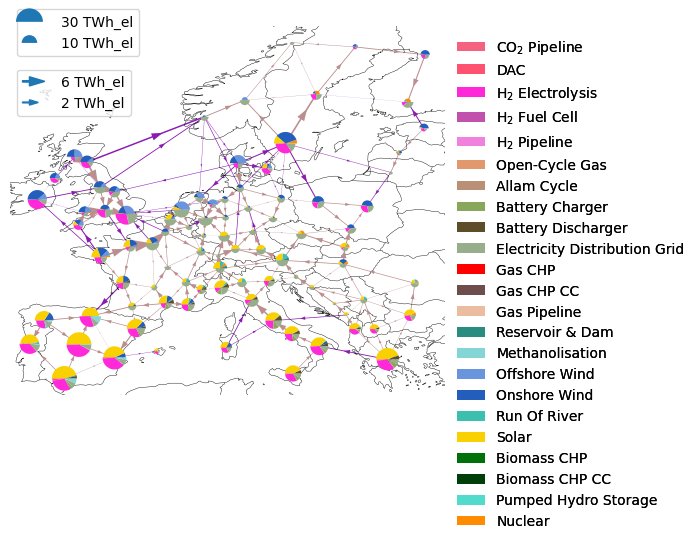

In [21]:
# energy balance — split half-circles + flow arrows (schema defaults)
fig, ax = s.energy_balance.plot.map(bus_carrier="AC")

/home/fabian/vres/py/oet/pypsa-training-sessions/.venv/lib/python3.12/site-packages/pypsa/plot/statistics/maps.py:238: UserWarning:

When combining n.plot() with other plots on a geographical axis, ensure n.plot() is called first or the final axis extent is set initially (ax.set_extent(boundaries, crs=crs)) for consistent legend semicircle sizes.



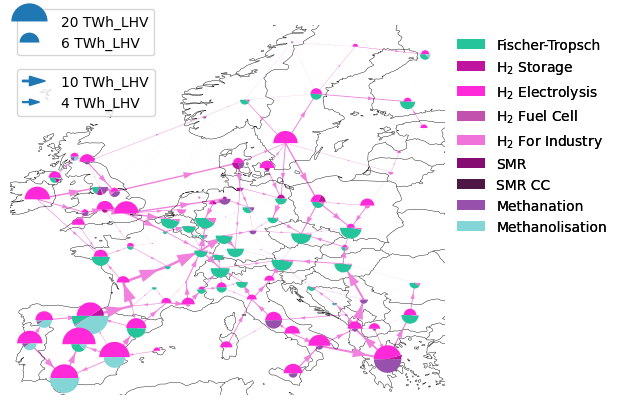

In [22]:
# H2 network — sector coupling highlight
fig, ax = s.energy_balance.plot.map(bus_carrier="H2")

/home/fabian/vres/py/oet/pypsa-training-sessions/.venv/lib/python3.12/site-packages/pypsa/plot/statistics/maps.py:253: UserWarning:

When combining n.plot() with other plots on a geographical axis, ensure n.plot() is called first or the final axis extent is set initially (ax.set_extent(boundaries, crs=crs)) for consistent legend circle sizes.



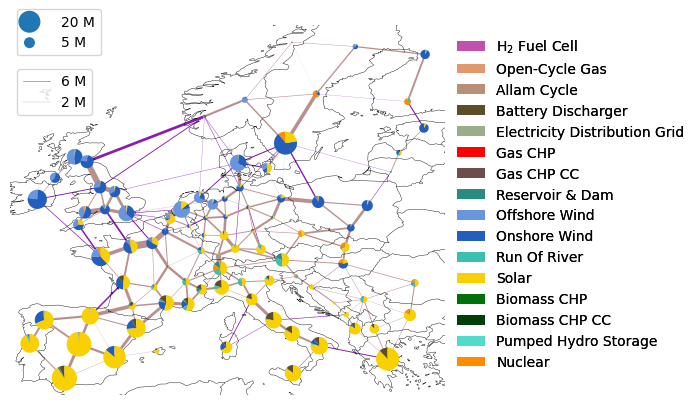

In [23]:
# supply with branch widths instead of flow arrows
fig, ax = s.supply.plot.map(
    bus_carrier="AC",
    transmission_flow=False,
    draw_legend_arrows=False,
    draw_legend_lines=True,
)

/home/fabian/vres/py/oet/pypsa-training-sessions/.venv/lib/python3.12/site-packages/pypsa/plot/statistics/maps.py:253: UserWarning:

When combining n.plot() with other plots on a geographical axis, ensure n.plot() is called first or the final axis extent is set initially (ax.set_extent(boundaries, crs=crs)) for consistent legend circle sizes.



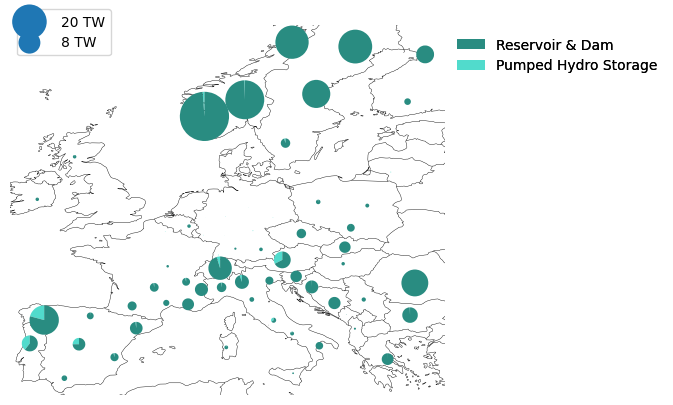

In [57]:
# storage capacity (allowed only for optimal_capacity / installed_capacity)
fig, ax = s.optimal_capacity.plot.map(bus_carrier="AC", storage=True)

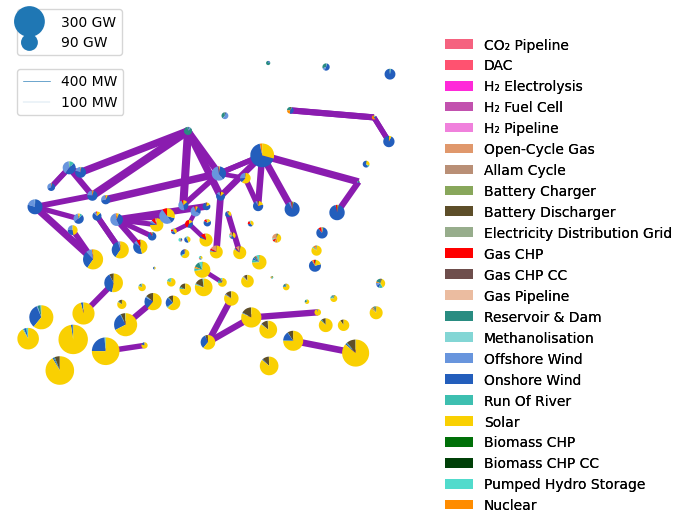

In [60]:
# zoom to Europe, bigger markers, no cartopy basemap
fig, ax = s.optimal_capacity.plot.map(
    bus_carrier="AC",
    geomap=False,
    boundaries=(-10, 30, 35, 70),
    bus_area_fraction=0.04,
)

/home/fabian/vres/py/oet/pypsa-training-sessions/.venv/lib/python3.12/site-packages/pypsa/plot/statistics/maps.py:253: UserWarning:

When combining n.plot() with other plots on a geographical axis, ensure n.plot() is called first or the final axis extent is set initially (ax.set_extent(boundaries, crs=crs)) for consistent legend circle sizes.



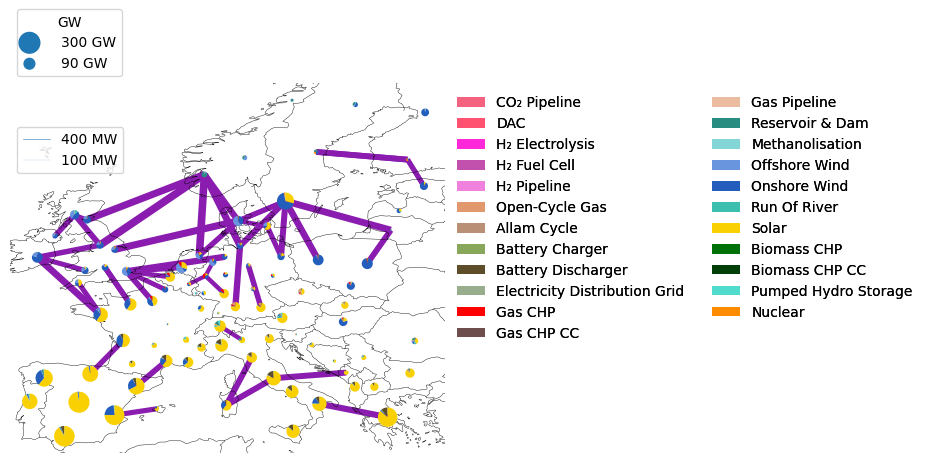

In [61]:
# customise legends
fig, ax = s.optimal_capacity.plot.map(
    bus_carrier="AC",
    legend_circles_kw={"bbox_to_anchor": (0, 1.0), "title": "GW"},
    legend_patches_kw={"ncol": 2, "bbox_to_anchor": (1, 1)},
)

:::{note} Map kwargs at a glance
- `bus_carrier` — pick one (required in sector-coupled networks)
- `carrier` — filter components
- `transmission_flow` — branch widths (`False`) vs flow arrows (`True`). Default
  is `True` for `supply` / `withdrawal` / `energy_balance`, `False` elsewhere.
- `bus_split_circle` — pos/neg split halves; default `True` for `energy_balance`.
- `bus_area_fraction` / `branch_area_fraction` / `flow_area_fraction` —
  auto-scaling targets (fraction of plot area). Default `0.02`.
- `geomap` / `geomap_resolution` / `geomap_color` / `projection` / `boundaries`
  — basemap controls.
- `legend_circles_kw` / `legend_lines_kw` / `legend_arrows_kw` / `legend_patches_kw`
  — dict of matplotlib legend kwargs each.
:::

# Styling & customization

Push the accessors without escaping to raw matplotlib.

## Carrier colors

When `color in (None, "carrier")` the palette comes from `n.carriers.color`. In
plotly the same colors become `color_discrete_map`. Set `nice_names=False` for
raw carrier identifiers.

In [27]:
n.carriers[["nice_name", "color"]].head()

,nice_name,color
name,,
process emissions CC,Process Emission CC,#000000
solid biomass CHP CC,Biomass CHP CC,#004008
biomass boiler,Biomass Boiler,#006030
solid biomass CHP,Biomass CHP,#007008
solid biomass,Biomass,#008020


(<Figure size 411.111x400 with 1 Axes>,
 <Axes: xlabel='Capital Expenditure [currency]', ylabel='carrier'>,
 <seaborn.axisgrid.FacetGrid at 0x7ebe489ed880>)

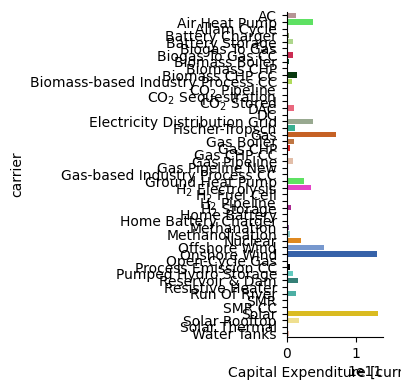

In [28]:
s.capex.plot.bar()  # carrier colors applied automatically

## Sizing & stacking

(<Figure size 411.111x400 with 1 Axes>,
 <Axes: xlabel='Capital Expenditure [currency]', ylabel='carrier'>,
 <seaborn.axisgrid.FacetGrid at 0x7ebe4899aed0>)

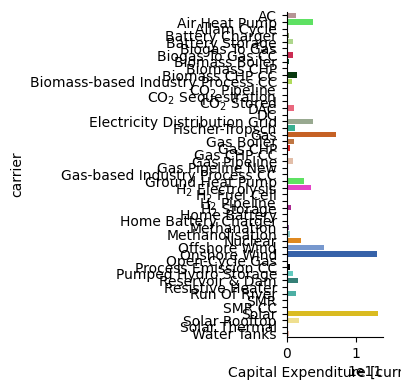

In [29]:
# bar stacking off → grouped bars
s.capex.plot.bar(stacked=False)

(<Figure size 811.111x400 with 1 Axes>,
 <Axes: xlabel='Capital Expenditure [currency]', ylabel='carrier'>,
 <seaborn.axisgrid.FacetGrid at 0x7ebe43f3c5f0>)

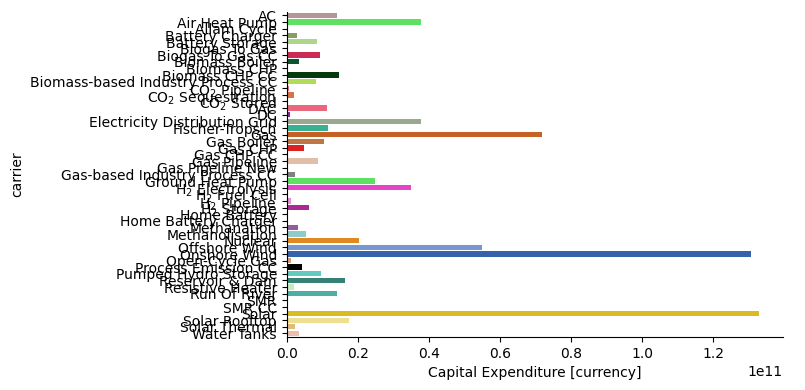

In [30]:
# matplotlib facet sizing (seaborn FacetGrid)
s.capex.plot.bar(height=4, aspect=2)

In [31]:
# plotly sizing in pixels
s.capex.iplot.bar(height=500, width=900, title="CAPEX by carrier")

## Faceting

Pass `facet_col` / `facet_row` to split by any long-format column (`bus_carrier`,
`carrier`, `snapshot`, `period`, `scenario`, `name`). Pair with a list-valued
filter to limit the panels.

In [32]:
s.energy_balance.iplot.area(
    bus_carrier=["AC", "H2"],
    facet_col="bus_carrier",
)

## Drop down to the underlying figure/axes

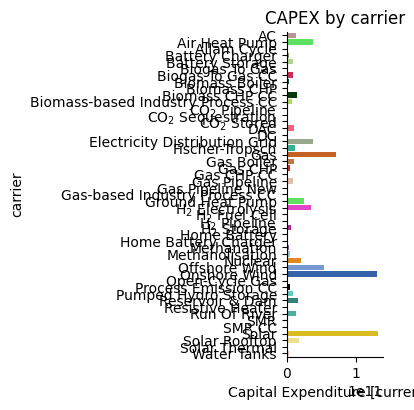

In [33]:
fig, ax, g = s.capex.plot.bar()
ax.set_title("CAPEX by carrier")
fig.savefig("capex.png", dpi=150)

In [34]:
fig = s.energy_balance.iplot.area(bus_carrier="AC")
fig.update_layout(title="AC dispatch", height=500)

:::{tip}
Extra `**kwargs` flow to the underlying seaborn / plotly.express call —
e.g. `facet_col_wrap=2` on plotly, `despine=False` on matplotlib.
:::

## Recap

| Plot type | `.plot` | `.iplot` | Best for |
|---|---|---|---|
| `bar` | ✓ | ✓ | totals by carrier / region |
| `line` | ✓ | ✓ | dispatch / price curves |
| `area` | ✓ | ✓ | stacked dispatch |
| `box` / `violin` / `histogram` | ✓ | ✗ | distribution of hourly values |
| `scatter` | ✓ | ✗ | per-carrier 2D layouts |
| `map` | ✓ | ✗ | spatial / network view |

:::{tip} Tips and tricks
- Call the accessor on the **method**, not its result: `s.capex.plot.bar()` ✅.
- Filter with `carrier=` / `bus_carrier=` / `query=`.
- Reshape with `x` / `y` / `color` / `facet_col` / `facet_row` — these replace
  the `groupby*` knobs.
- Never pass `groupby`, `groupby_time`, `aggregate_across_components` — they're derived.
- `.iplot` is limited to `bar`/`line`/`area`. For everything else, use `.plot`.
- `.iplot.map` does not exist — only `.plot.map`.
- For sector-coupled networks, **always** set `bus_carrier`.
- `.plot.*` returns `(fig, ax, FacetGrid)`; `.iplot.*` returns a plotly `Figure`.
- Colors come from `n.carriers.color` — set them once, get consistent figures everywhere.
:::

:::{seealso}
[pypsa.org/latest/user-guide/statistics](https://docs.pypsa.org/latest/user-guide/statistics/) — plotting section.
:::